In [110]:
import numpy as np
from lr_utils import load_dataset

In [111]:
X_train_orig, y_train, X_test_orig, y_test, classes = load_dataset()

In [112]:
X_train = X_train_orig.reshape(X_train_orig.shape[0],-1).T / 255
X_test = X_test_orig.reshape(X_test_orig.shape[0],-1).T / 255

In [113]:
def sigmoid(x):
    s = 1 / (1+np.exp(-x))
    return s

In [114]:
def initilize_with_zero(X_train):
    w, b = np.zeros((X_train.shape[0],1)), 0.
    return w, b

In [115]:
def forward(X_train, y_train, w, b):
    a_train = sigmoid(np.dot(w.T, X_train) + b)
    loss = - np.sum(y_train * np.log(a_train) + (1-y_train) * np.log(1-a_train), axis=1) / X_train.shape[1]
    return a_train, np.squeeze(loss)

In [116]:
def backward(X_train, y_train, a_train, w, b, learning_rate):
    dw = np.dot(X_train, (a_train-y_train).T) / X_train.shape[1]
    db = np.sum(a_train-y_train) / X_train.shape[0]
    #grads = {
    #    "dw" : dw,
    #    "db" : db
    #}
    w = w - learning_rate*dw
    b = b - learning_rate*db

    return w, b

In [117]:
def test(X_test, y_test, w, b):
    a_test = sigmoid(np.dot(w.T, X_test) + b)
    loss = - np.sum(y_test * np.log(a_test) + (1-y_test) * np.log(1-a_test), axis=1) / X_test.shape[1]
    return np.squeeze(loss)

In [118]:
def model(X_train, y_train, X_test, y_test, number_of_iterations, learning_rate):
    train_losses = []
    test_losses = []
    w, b = initilize_with_zero(X_train)
    for i in range(number_of_iterations):
        a_train, train_loss = forward(X_train, y_train, w, b)
        test_loss = test(X_test, y_test, w, b)

        if i%100 == 0:
            train_losses.append(train_loss)
            test_losses.append(test_loss)
        
        w, b = backward(X_train, y_train, a_train, w, b, learning_rate)


    return w, b, train_losses, test_losses

In [208]:
w, b, train_losses, test_losses = model(X_train, y_train, X_test, y_test, number_of_iterations=2000, learning_rate=0.001)

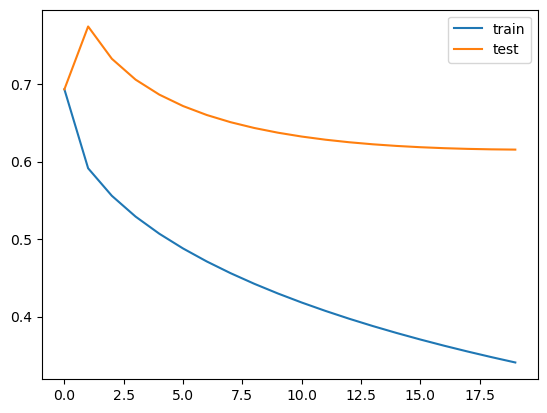

In [209]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label = "train")
plt.plot(test_losses, label = "test")
plt.legend()
plt.show()


In [212]:
a_train = sigmoid(np.dot(w.T, X_train) + b)
a_test = sigmoid(np.dot(w.T, X_test) + b)
train_accuracy =  np.sum((a_train >= 0.5) == (y_train == 1)) / X_train.shape[1]
test_accuracy = np.sum((a_test >= 0.5) == (y_test == 1)) / X_test.shape[1]
print(f"Train accuracy = {train_accuracy * 100}%")
print(f"Test accuracy = {test_accuracy * 100}%")

Train accuracy = 91.38755980861244%
Test accuracy = 68.0%


In [202]:
def predict_one_image(image, w, b):
    image_vector = image.reshape(-1,1) / 255
    y_pre = sigmoid(np.dot(w.T, image_vector) + b)
    if y_pre >= 0.5:
        return "cat"
    else:
        return "non cat"

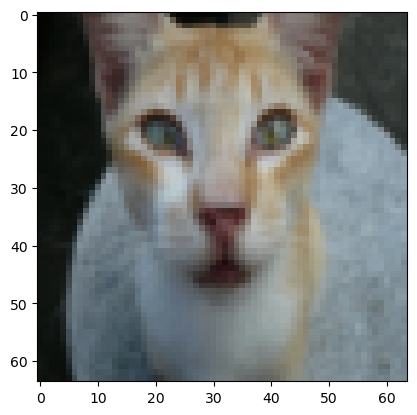

cat


In [203]:
# Example of a picture
index =11
plt.imshow(X_train_orig[index])
plt.show()

print(predict_one_image(X_train_orig[index], w, b))